# Ajuste BEG en picos dQdV

In [1]:
from pathlib import Path
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
import func_deriv as func_deriv
import func_plots as func_plots
from scipy.optimize import curve_fit
from scipy.signal import find_peaks


In [2]:
# %% ------- Cargar ciclos ------------------------------------------------------------
input_folder = Path('/home/mariajose/proc-icdv/tmp')
nombre_archivo = "NMC-20"
output_folder = Path('/home/mariajose/proc-icdv/output')
output_folder.mkdir(parents=True, exist_ok=True)  # Create output directory if it doesn't exist

with open(input_folder / f'{nombre_archivo}.json') as f_json:
    raw_dict = json.load(f_json)

dict_ciclos_sep = {
    int(ciclo): {
        etapa: pd.DataFrame(data) for etapa, data in etapas.items()
    }
    for ciclo, etapas in raw_dict.items()
}

indices_ciclos = list(dict_ciclos_sep.keys())

In [3]:
# %% ------- Elegir ciclos ------------------------------------------------------------

# Elijo en todo el rango, equiespaciados
N_ciclos = 10  # Número de ciclos a tomar, si no se especifica, toma todos los del archivo
indices_ciclos_ = indices_ciclos[:-1] # Quito el último
indices_ciclos_array = np.array(indices_ciclos_)
ciclos_disponibles = sorted(dict_ciclos_sep.keys())
ciclos_seleccionados = indices_ciclos_array[np.linspace(0, len(indices_ciclos_array)-1, N_ciclos, dtype=int)]
#print("Ciclos seleccionados:", ciclos_seleccionados)
#print(f"son {len(ciclos_seleccionados)} ciclos")

# Elecciones manuales
#ciclos_reducidos = [3, 21, 78, 153, 228, 303, 378, 453, 528, 603, 678, 753, 828]
#ciclos_seleccionados = [2, 99, 192, 300, 414, 504, 600, 702, 801, 897]
ciclos_seleccionados = [2, 21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
ciclos_seleccionados = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]


excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados = [c for c in ciclos_disponibles if 21 <= c <= 300 and c not in excluir]

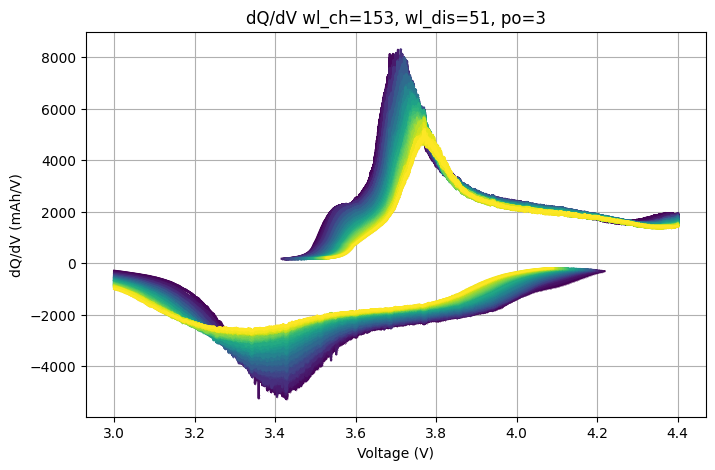

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...\n        }\n"

In [4]:
# %% ------- Trunco datos y calculo derivada ------------------------------------------------------------

# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

diccio = func_deriv.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)
diccio =  func_deriv.plot_dqdv(ciclos_seleccionados, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...
        }
'''
# Exportar a csv para trabajar en Origin
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

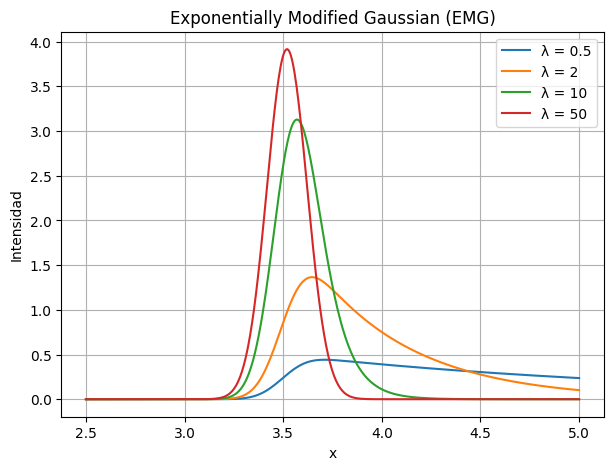

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

def emg(x, a, mu, sigma, lambd):
    """
    Exponentially Modified Gaussian (EMG)

    x: array
    a: amplitud
    mu: media gaussiana
    sigma: desviación estándar
    lambd: parámetro de decaimiento exponencial
    """
    return (a * (lambd/2) *
            np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
            erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))

# Rango de x
x = np.linspace(2.5, 5.0, 500)

# Parámetros de prueba
a = 1.0
mu = 3.5
sigma = 0.1

plt.figure(figsize=(7,5))

for lambd in [0.5, 2, 10, 50]:
    y = emg(x, a, mu, sigma, lambd)
    plt.plot(x, y, label=f"λ = {lambd}")

plt.xlabel("x")
plt.ylabel("Intensidad")
plt.title("Exponentially Modified Gaussian (EMG)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# %% ------- Defino funciones ajuste ------------------------------------------------------------

from scipy.special import erfc
import numpy as np

def emg(x, a, mu, sigma, lambd):
    """
    Exponentially Modified Gaussian (EMG)
    
    x: array de valores
    a: amplitud
    mu: media de la gaussiana
    sigma: desviación estándar
    lambd: parámetro de decaimiento exponencial (1/tau)
    """
    return (a * (lambd/2) *
            np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
            erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))


def multi_emg(x, *params):
    """
    params: [a1, mu1, sigma1, lambda1, a2, mu2, sigma2, lambda2, ...]
    """
    y = np.zeros_like(x)
    for i in range(0, len(params), 4):
        a, mu, sigma, lambd = params[i:i+4]
        y += (a * (lambd/2) *
              np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
              erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))
    return y



def multi_emg_lamfijo(V, *params, lam_fijo=0.5):
    y = 0
    n_peaks = len(params)//3
    for i in range(n_peaks):
        a, mu, sigma = params[3*i:3*i+3]
        y += emg(V, a, mu, sigma, lam_fijo)
    return y

In [7]:
# parámetros iniciales para cada pico (a, mu, sigma)
p_ini = [
    100, 3.51, 0.5,   # pico 1
    1500, 3.6, 0.003,  # pico 2
    11000, 3.95, 0.02,    # pico 3
    2200, 4.39, 0.1     # pico 4
]

n_peaks = len(p_ini) // 3

# valores iniciales de lambda elegidos a mano, uno por pico
lambda_inis = [
    0.4,   # lambda inicial para pico 1
    5,  # lambda inicial para pico 2
    0.2,  # lambda inicial para pico 3
    7  # lambda inicial para pico 4
]

# construir p_ini_emg
p_ini_emg = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    p_ini_emg += [a0, mu0, sigma0, lam0]

# bounds: podés también personalizar cada lambda
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    lb += [0, mu0-0.05, 1e-6, 0]  # lambda >= 10% del inicial
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]  # lambda <= 10x inicial

bounds_emg = (lb, ub)


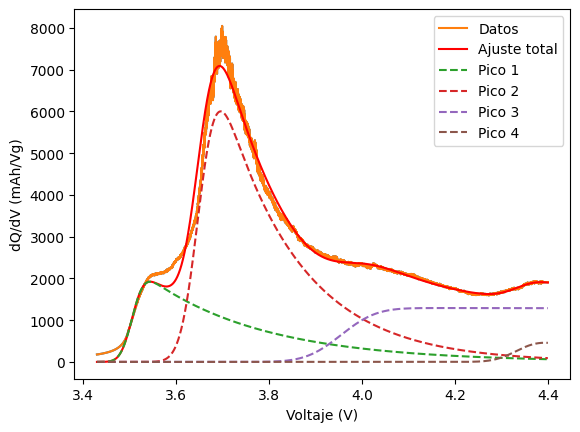

Parámetros ajustados (a, mu, sigma, lambda) por pico:
Pico 1: a=576.5431527161704, mu=3.505867320801006, sigma=0.019855081824952762, lambda=3.9999999999999996
Pico 2: a=1412.0362950561098, mu=3.6499999999999995, sigma=0.0304728641923557, lambda=6.097174525675393
Pico 3: a=117585.385501671, mu=3.9550059430901108, sigma=0.05955231557020666, lambda=0.011006663985258425
Pico 4: a=110.7434817323217, mu=4.340000000000001, sigma=0.04038559803222747, lambda=6.697321434693992


In [8]:
# %% ------- Pruebo con el primer ciclo ------------------------------------------------------------

df_ch = diccio[21]['Ch']
df_dis = diccio[21]['Dis']

dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 

plt.plot(V, dqdv_ch_calc)

# Ajuste
popt, pcov = curve_fit(multi_emg, V, dqdv_ch_calc, p0=p_ini_emg, bounds=bounds_emg)

# Curva total ajustada
y_fit = multi_emg(V, *popt)
plt.plot(V, dqdv_ch_calc, label="Datos")
plt.plot(V, y_fit, 'r-', label="Ajuste total")

# Dibujar cada gaussiana individual
for i in range(0, len(popt), 4):
    a, mu, sigma, lambd = popt[i:i+4]
    plt.plot(V, emg(V, a, mu, sigma, lambd), '--', label=f"Pico {i//4 + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'./output/ajuste_picos.png', dpi=300)
plt.show()

print("Parámetros ajustados (a, mu, sigma, lambda) por pico:")
for i in range(n_peaks):
    a, mu, sigma, lambd = popt[i*4:i*4+4]
    print(f"Pico {i+1}: a={a}, mu={mu}, sigma={sigma}, lambda={lambd}")

## Loop para muchos ciclos

In [10]:
# parámetros iniciales para cada pico (a, mu, sigma)
p_ini = [
    900, 3.55, 0.02,   # pico 1
    5900, 3.6, 0.013,  # pico 2
    11000, 4.0, 0.02,    # pico 3
    2200, 4.39, 0.1     # pico 4
]

n_peaks = len(p_ini) // 3

# valores iniciales de lambda elegidos a mano, uno por pico
lambda_inis = [
    0.7,   # lambda inicial para pico 1
    4,  # lambda inicial para pico 2
    5,  # lambda inicial para pico 3
    100.0  # lambda inicial para pico 4
]

# construir p_ini_emg
p_ini_emg = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    p_ini_emg += [a0, mu0, sigma0, lam0]

# bounds: podés también personalizar cada lambda
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    lb += [0, mu0-0.05, 1e-6, lam0*0.1]  # lambda >= 10% del inicial
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]  # lambda <= 10x inicial

bounds_emg = (lb, ub)

In [12]:
# %% ------- Ajuste encadenado de varios ciclos ------------------------------------------------------------

# ---- Elegir ciclos del loop y nombre del .csv ------------------------------------------------
nombre = 'EMG_casifijo_lambda_50bounds'
excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados_ajuste = [c for c in ciclos_disponibles if 21 <= c <= 300 and c not in excluir]
ciclos_grafico = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
# ----------------------------------------------------------------------------------------------

ciclos = ciclos_seleccionados_ajuste     # los que quieras ajustar
resultados = []                           # lista de parámetros ajustados
covs = []                                # lista de matrices de covarianza
areas = []                               # lista de áreas de cada pico

colors = cm.tab10.colors  # paleta con 10 colores distintos

# inicialización con p_ini
p0_actual = p_ini_emg
bounds_actual = bounds_emg
n_peaks = len(p_ini_emg)//4

# Realizar ajustes
for ciclo in ciclos:
    try:
        df_ch = diccio[ciclo]['Ch']
        V = df_ch['V_ch_savgol']
        dqdv = df_ch['dqdv_ch_calc']
        
        # Ajuste
        print(f'Ajustando ciclo {ciclo}...')
        popt, pcov = curve_fit(multi_emg, V, dqdv, p0=p0_actual, bounds=bounds_actual,
                               maxfev=8000   # por defecto suele ser 800
                                )
    
        # Guardar resultados
        resultados.append(popt)
        covs.append(pcov)
        
        # Calcular áreas de cada gaussiana
        #areas_picos = []
        #for i in range(0, len(popt), 3):
        #    a, mu, sigma = popt[i:i+3]
        #    area = a * sigma * np.sqrt(2*np.pi)
        #    areas_picos.append(area)
        #areas.append(areas_picos)
    
        # Actualizar p0 para el siguiente ciclo
        p0_actual = popt

        # --- recalcular bounds para el próximo ciclo ---
        lb = []
        ub = []
        for i in range(n_peaks):
            a0, mu0, sigma0, lam0 = popt[4*i:4*i+4]
            lb += [0.5*a0, 0.5*mu0, 0.5*sigma0, lam0*0.0000009]
            ub += [1.5*a0, 1.5*mu0, 1.5*sigma0, lam0*1.0000001]
        bounds_actual = (lb, ub)
    
    except Exception as e:
        # si falla, llenar con NaN
        resultados.append([np.nan,np.nan,np.nan,np.nan] * n_peaks)
        covs.append(np.full((n_peaks*4, n_peaks*4), np.nan))  # matriz covarianza "vacía"
        areas.append([np.nan] * n_peaks)
    
    # Plot
    if ciclo in ciclos_grafico:
        plt.figure()
        y_fit = multi_emg(V, *popt)
        plt.plot(V, dqdv, label=f"Datos ciclo {ciclo}", color='black')
        plt.plot(V, y_fit, 'r-', label="Ajuste total")

        for i in range(0, len(popt), 4):
            a, mu, sigma, lam = popt[i:i+4]
            j = i // 4   # índice de pico: 0,1,2,...
            plt.plot(V, emg(V, a, mu, sigma, lam), '--', color=colors[j % len(colors)], label=f"Pico {j + 1}")

        plt.legend()
        plt.ylim(-300,8500)
        plt.xlabel("Voltaje (V)")
        plt.ylabel("dQ/dV (mAh/Vg)")
        plt.title(f"Ajuste ciclo {ciclo}")
        plt.savefig(f'./output/ajuste_picos_ciclo{ciclo}_{nombre}.png', dpi=300)
        plt.close()

# %% ------- Crear DataFrame con parámetros y áreas ------------------------------------------------------------
cols = []
cols_area = []

for i in range(n_peaks):
    cols += [f"a{i+1}", f"mu{i+1}", f"sigma{i+1}", f"lambda{i+1}"]
    cols_area.append(f"area{i+1}")

df_params = pd.DataFrame(resultados, index=ciclos, columns=cols)
df_areas = pd.DataFrame(areas, index=ciclos, columns=cols_area)
df_final = pd.concat([df_params, df_areas], axis=1)

# Guardar a CSV
df_final.to_csv(f"./output/parametros_ajustes_{nombre}.csv")

print(f"Ajustes terminados. Resultados guardados en './output/parametros_ajustes_{nombre}.csv'")


Ajustando ciclo 21...
Ajustando ciclo 24...
Ajustando ciclo 27...
Ajustando ciclo 33...
Ajustando ciclo 36...
Ajustando ciclo 39...
Ajustando ciclo 42...
Ajustando ciclo 45...
Ajustando ciclo 48...
Ajustando ciclo 51...
Ajustando ciclo 54...
Ajustando ciclo 57...
Ajustando ciclo 60...
Ajustando ciclo 63...
Ajustando ciclo 66...
Ajustando ciclo 69...
Ajustando ciclo 72...
Ajustando ciclo 75...
Ajustando ciclo 78...
Ajustando ciclo 81...
Ajustando ciclo 84...
Ajustando ciclo 87...
Ajustando ciclo 90...
Ajustando ciclo 93...
Ajustando ciclo 96...
Ajustando ciclo 99...
Ajustando ciclo 102...
Ajustando ciclo 105...
Ajustando ciclo 108...
Ajustando ciclo 111...
Ajustando ciclo 114...
Ajustando ciclo 117...
Ajustando ciclo 120...
Ajustando ciclo 123...
Ajustando ciclo 126...
Ajustando ciclo 129...
Ajustando ciclo 132...
Ajustando ciclo 135...
Ajustando ciclo 138...
Ajustando ciclo 141...
Ajustando ciclo 144...
Ajustando ciclo 147...
Ajustando ciclo 150...
Ajustando ciclo 153...
Ajustando cicl

In [79]:
df_final = pd.read_csv("./output/parametros_ajustes_EMG_casifijo_lambda.csv", index_col=0)

df_final.head()

,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3,a4,mu4,sigma4,lambda4,area1,area2,area3,area4
21,402.533244,3.510705,0.023230,7.000000,1548.485911,3.650000,0.030945,5.798317,2973.587031,3.957266,0.066182,0.500000,94.598771,4.394089,0.064208,379.042481,NaN,NaN,NaN,NaN
24,442.786569,3.520645,0.025553,7.000001,1483.545617,3.654364,0.029082,5.798318,3270.945734,3.953413,0.065297,0.436268,102.564941,4.392073,0.067897,378.904958,NaN,NaN,NaN,NaN
27,486.041319,3.525662,0.028108,7.000001,1478.957255,3.656780,0.026174,5.798318,3598.038146,3.957168,0.059525,0.392447,94.680024,4.400251,0.065297,378.763584,NaN,NaN,NaN,NaN
33,534.645450,3.532571,0.030919,7.000002,1396.716527,3.662228,0.023556,5.798319,3957.841955,3.948769,0.063460,0.359429,86.724914,4.409941,0.058767,378.763375,NaN,NaN,NaN,NaN
36,558.602827,3.531842,0.034011,7.000003,1386.180219,3.662591,0.023439,5.798319,4353.626150,3.959418,0.063366,0.336885,78.052423,4.398434,0.052891,61.832927,NaN,NaN,NaN,NaN


### Evolucion parámetros

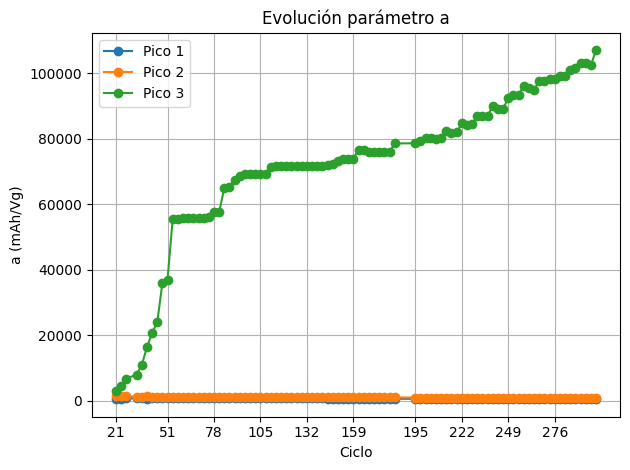

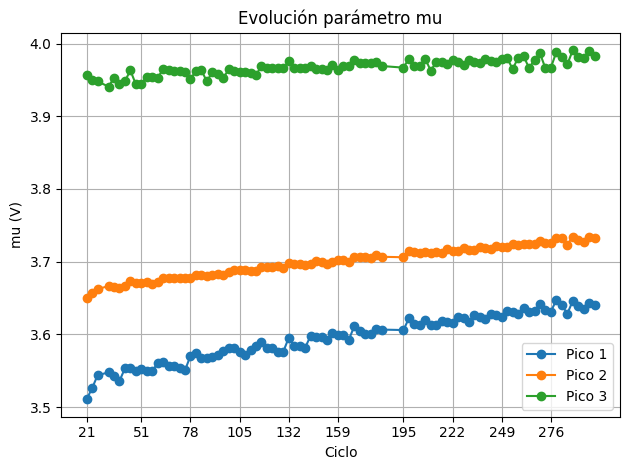

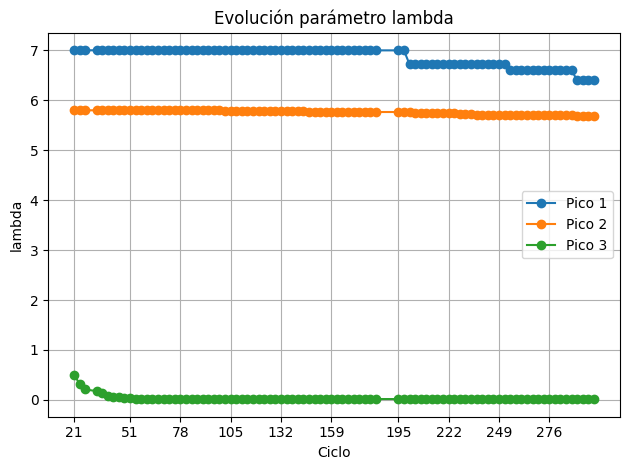

In [81]:
# %% ------------ Graficar evolución de los parámetros con los ciclos  ----------------------------------------

# ------ Elegir cuál y de qué loop ---------------
#df_final = pd.read_csv("./output/parametros_ajustes.csv", index_col=0)
#df_final = pd.read_csv("./output/parametros_ajustes_EMG.csv", index_col=0)
df_final = pd.read_csv("./output/parametros_ajustes_EMG_casifijo_lambda_50bounds.csv", index_col=0)
nombre = 'EMG' # etiqueta gráfico
# ------------------------------------------------

n_peaks = len(p_ini_emg)//4
colors = cm.tab10.colors  # paleta con 10 colores distintos

# Evolución de la altura (a)
plt.figure()
for i in range(n_peaks): # 0,1,2
    if i not in [3]:  # excluir el pico 4 si es necesario
        plt.plot(df_final.index, df_final[f"a{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("a (mAh/Vg)")
plt.xticks(df_final.index[::9])
plt.title("Evolución parámetro a")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_a_{nombre}.png", dpi=300)
plt.show()

# Evolución de la posición (mu)
plt.figure()
for i in range(n_peaks):
    if i not in [3]:  # excluir el pico 4 si es necesario
        plt.plot(df_final.index, df_final[f"mu{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("mu (V)")
plt.xticks(df_final.index[::9])
plt.title("Evolución parámetro mu")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_mu_{nombre}.png", dpi=300)
plt.show()

# Evolución del área
plt.figure()
for i in range(n_peaks):
    if i not in [3]:  # excluir el pico 4 si es necesario
        plt.plot(df_final.index, df_final[f"lambda{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("lambda")
plt.xticks(df_final.index[::9])
plt.title("Evolución parámetro lambda")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_lambda_{nombre}.png", dpi=300)
plt.show()